In [1]:
pip install pandas numpy scikit-learn joblib matplotlib

In [2]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


class SICEnsemble:

    def __init__(self, n_models=5):
        self.models = []

        for i in range(n_models):
            model = RandomForestRegressor(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=2,
                random_state=i,
                n_jobs=-1
            )

            self.models.append(model)

    def train(self, X, y):

        for i, model in enumerate(self.models):

            # Bootstrap sampling
            indices = np.random.choice(
                len(X),
                size=len(X),
                replace=True
            )

            X_bootstrap = X.iloc[indices]
            y_bootstrap = y.iloc[indices]

            model.fit(X_bootstrap, y_bootstrap)

            print(f"Model {i + 1} trained")

    def predict(self, X):

        predictions = []

        for model in self.models:
            pred = model.predict(X)
            predictions.append(pred)

        predictions = np.array(predictions)

        mean_prediction = predictions.mean(axis=0)
        std_prediction = predictions.std(axis=0)

        lower = mean_prediction - 1.96 * std_prediction
        upper = mean_prediction + 1.96 * std_prediction

        # SIC must remain between 0 and 100
        mean_prediction = np.clip(mean_prediction, 0, 100)
        lower = np.clip(lower, 0, 100)
        upper = np.clip(upper, 0, 100)

        return {
            "prediction": mean_prediction,
            "uncertainty": std_prediction,
            "lower": lower,
            "upper": upper,
            "individual_predictions": predictions
        }

    def evaluate(self, X_test, y_test):

        result = self.predict(X_test)

        prediction = result["prediction"]

        mae = mean_absolute_error(y_test, prediction)
        rmse = np.sqrt(mean_squared_error(y_test, prediction))
        r2 = r2_score(y_test, prediction)

        print("\nMODEL PERFORMANCE")
        print("-----------------")
        print(f"MAE  : {mae:.2f}")
        print(f"RMSE : {rmse:.2f}")
        print(f"R²   : {r2:.3f}")

        return mae, rmse, r2

In [9]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


class SICEnsemble:

    def __init__(self, n_models=5):
        self.models = []

        for i in range(n_models):
            model = RandomForestRegressor(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=2,
                random_state=i,
                n_jobs=-1
            )

            self.models.append(model)

    def train(self, X, y):

        for i, model in enumerate(self.models):

            # Bootstrap sampling
            indices = np.random.choice(
                len(X),
                size=len(X),
                replace=True
            )

            X_bootstrap = X.iloc[indices]
            y_bootstrap = y.iloc[indices]

            model.fit(
                X_bootstrap,
                y_bootstrap
            )

            print(f"Model {i + 1}/5 trained")

    def predict(self, X):

        predictions = []

        for model in self.models:
            predictions.append(
                model.predict(X)
            )

        predictions = np.array(predictions)

        mean_prediction = predictions.mean(axis=0)
        uncertainty = predictions.std(axis=0)

        lower = mean_prediction - 1.96 * uncertainty
        upper = mean_prediction + 1.96 * uncertainty

        # SIC must be between 0 and 100
        mean_prediction = np.clip(
            mean_prediction, 0, 100
        )

        lower = np.clip(
            lower, 0, 100
        )

        upper = np.clip(
            upper, 0, 100
        )

        return {
            "prediction": mean_prediction,
            "uncertainty": uncertainty,
            "lower": lower,
            "upper": upper,
            "individual_predictions": predictions
        }

    def evaluate(self, X_test, y_test):

        result = self.predict(X_test)

        prediction = result["prediction"]

        mae = mean_absolute_error(
            y_test,
            prediction
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                prediction
            )
        )

        r2 = r2_score(
            y_test,
            prediction
        )

        print("\nMODEL PERFORMANCE")
        print("=================")
        print(f"MAE  : {mae:.2f}")
        print(f"RMSE : {rmse:.2f}")
        print(f"R²   : {r2:.3f}")

        return mae, rmse, r2

In [40]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Number of samples
n = 5000

# Generate locations
latitude = np.random.uniform(65, 80, n)
longitude = np.random.uniform(-60, 20, n)

# Environmental variables
sst = np.random.uniform(-2, 5, n)

wind_speed = np.random.uniform(0, 20, n)

current_u = np.random.uniform(-0.5, 0.5, n)
current_v = np.random.uniform(-0.5, 0.5, n)

# Create synthetic SIC
sic = (
    75
    - 8 * sst
    - 0.8 * wind_speed
    + 10 * current_u
    - 5 * current_v
    + np.random.normal(0, 5, n)
)

# Keep SIC between 0 and 100
sic = np.clip(sic, 0, 100)

# Create dataframe
data = pd.DataFrame({
    "latitude": latitude,
    "longitude": longitude,
    "sst": sst,
    "wind_speed": wind_speed,
    "current_u": current_u,
    "current_v": current_v,
    "sic": sic
})

print("Synthetic dataset created!")
print("Shape:", data.shape)

display(data.head())

Synthetic dataset created!
Shape: (5000, 7)


,latitude,longitude,sst,wind_speed,current_u,current_v,sic
0,70.618102,-28.509158,0.615486,9.993405,0.229998,-0.407629,63.266058
1,79.260715,-22.125147,0.330385,14.934935,-0.315488,-0.439246,70.151869
2,75.979909,8.363791,-0.766923,11.253336,-0.153360,0.104192,78.406545
3,73.979877,-32.799649,2.250867,1.666052,0.163281,0.466116,58.617127
4,67.340280,9.571975,1.336369,3.711605,-0.017911,0.002721,59.431670


In [13]:
features = [
    "latitude",
    "longitude",
    "sst",
    "wind_speed",
    "current_u",
    "current_v"
]

target = "sic"

X = data[features]
y = data[target]

In [15]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 5000

# Location
latitude = np.random.uniform(65, 80, n)
longitude = np.random.uniform(-60, 20, n)

# Environmental conditions
sst = np.random.uniform(-2, 5, n)
wind_speed = np.random.uniform(0, 20, n)

current_u = np.random.uniform(-0.5, 0.5, n)
current_v = np.random.uniform(-0.5, 0.5, n)

# Synthetic SIC
sic = (
    75
    - 8 * sst
    - 0.8 * wind_speed
    + 10 * current_u
    - 5 * current_v
    + np.random.normal(0, 5, n)
)

sic = np.clip(sic, 0, 100)

data = pd.DataFrame({
    "latitude": latitude,
    "longitude": longitude,
    "sst": sst,
    "wind_speed": wind_speed,
    "current_u": current_u,
    "current_v": current_v,
    "sic": sic
})

print("✅ Dataset created!")
print("Shape:", data.shape)

display(data.head())

✅ Dataset created!
Shape: (5000, 7)


,latitude,longitude,sst,wind_speed,current_u,current_v,sic
0,70.618102,-28.509158,0.615486,9.993405,0.229998,-0.407629,63.266058
1,79.260715,-22.125147,0.330385,14.934935,-0.315488,-0.439246,70.151869
2,75.979909,8.363791,-0.766923,11.253336,-0.153360,0.104192,78.406545
3,73.979877,-32.799649,2.250867,1.666052,0.163281,0.466116,58.617127
4,67.340280,9.571975,1.336369,3.711605,-0.017911,0.002721,59.431670


In [16]:
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


class SICEnsemble:

    def __init__(self, n_models=5):

        self.models = []

        for i in range(n_models):

            model = RandomForestRegressor(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=2,
                random_state=i,
                n_jobs=-1
            )

            self.models.append(model)


    def train(self, X, y):

        for i, model in enumerate(self.models):

            indices = np.random.choice(
                len(X),
                size=len(X),
                replace=True
            )

            X_bootstrap = X.iloc[indices]
            y_bootstrap = y.iloc[indices]

            model.fit(
                X_bootstrap,
                y_bootstrap
            )

            print(f"✅ Model {i + 1}/5 trained")


    def predict(self, X):

        predictions = []

        for model in self.models:

            prediction = model.predict(X)

            predictions.append(prediction)

        predictions = np.array(predictions)

        # Average of all 5 models
        mean_prediction = predictions.mean(axis=0)

        # Spread between models
        uncertainty = predictions.std(axis=0)

        # Approximate prediction interval
        lower = mean_prediction - 1.96 * uncertainty
        upper = mean_prediction + 1.96 * uncertainty

        # SIC must be 0–100%
        mean_prediction = np.clip(
            mean_prediction,
            0,
            100
        )

        lower = np.clip(
            lower,
            0,
            100
        )

        upper = np.clip(
            upper,
            0,
            100
        )

        return {
            "prediction": mean_prediction,
            "uncertainty": uncertainty,
            "lower": lower,
            "upper": upper,
            "individual_predictions": predictions
        }


    def evaluate(self, X_test, y_test):

        result = self.predict(X_test)

        prediction = result["prediction"]

        mae = mean_absolute_error(
            y_test,
            prediction
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                prediction
            )
        )

        r2 = r2_score(
            y_test,
            prediction
        )

        print("\n============================")
        print("       MODEL PERFORMANCE")
        print("============================")

        print(f"MAE  : {mae:.3f}")
        print(f"RMSE : {rmse:.3f}")
        print(f"R²   : {r2:.3f}")

        return mae, rmse, r2

In [17]:
features = [
    "latitude",
    "longitude",
    "sst",
    "wind_speed",
    "current_u",
    "current_v"
]

target = "sic"

X = data[features]
y = data[target]


# ---------------------------------
# TRAIN / TEST SPLIT
# ---------------------------------

split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------
# TRAIN ENSEMBLE
# ---------------------------------

ensemble = SICEnsemble(n_models=5)

ensemble.train(
    X_train,
    y_train
)


# ---------------------------------
# EVALUATE
# ---------------------------------

ensemble.evaluate(
    X_test,
    y_test
)


# ---------------------------------
# FORECAST
# ---------------------------------

result = ensemble.predict(
    X_test.iloc[:5]
)


for i in range(5):

    print("\n-----------------------")
    print(f"FORECAST {i + 1}")
    print("-----------------------")

    print(
        f"SIC: "
        f"{result['prediction'][i]:.2f}%"
    )

    print(
        f"Uncertainty: "
        f"±{result['uncertainty'][i]:.2f}%"
    )

    print(
        f"Range: "
        f"{result['lower'][i]:.2f}% - "
        f"{result['upper'][i]:.2f}%"
    )

Training samples: 4000
Testing samples: 1000
✅ Model 1/5 trained
✅ Model 2/5 trained
✅ Model 3/5 trained
✅ Model 4/5 trained
✅ Model 5/5 trained

       MODEL PERFORMANCE
MAE  : 4.180
RMSE : 5.253
R²   : 0.915

-----------------------
FORECAST 1
-----------------------
SIC: 85.24%
Uncertainty: ±0.63%
Range: 84.01% - 86.48%

-----------------------
FORECAST 2
-----------------------
SIC: 81.58%
Uncertainty: ±0.61%
Range: 80.38% - 82.78%

-----------------------
FORECAST 3
-----------------------
SIC: 48.89%
Uncertainty: ±1.39%
Range: 46.17% - 51.60%

-----------------------
FORECAST 4
-----------------------
SIC: 67.29%
Uncertainty: ±0.71%
Range: 65.91% - 68.68%

-----------------------
FORECAST 5
-----------------------
SIC: 38.06%
Uncertainty: ±0.52%
Range: 37.05% - 39.08%


In [20]:
print("y_test:", len(y_test))
print("prediction:", len(result["prediction"]))
print("lower:", len(result["lower"]))
print("upper:", len(result["upper"]))

y_test: 1000
prediction: 5
lower: 5
upper: 5


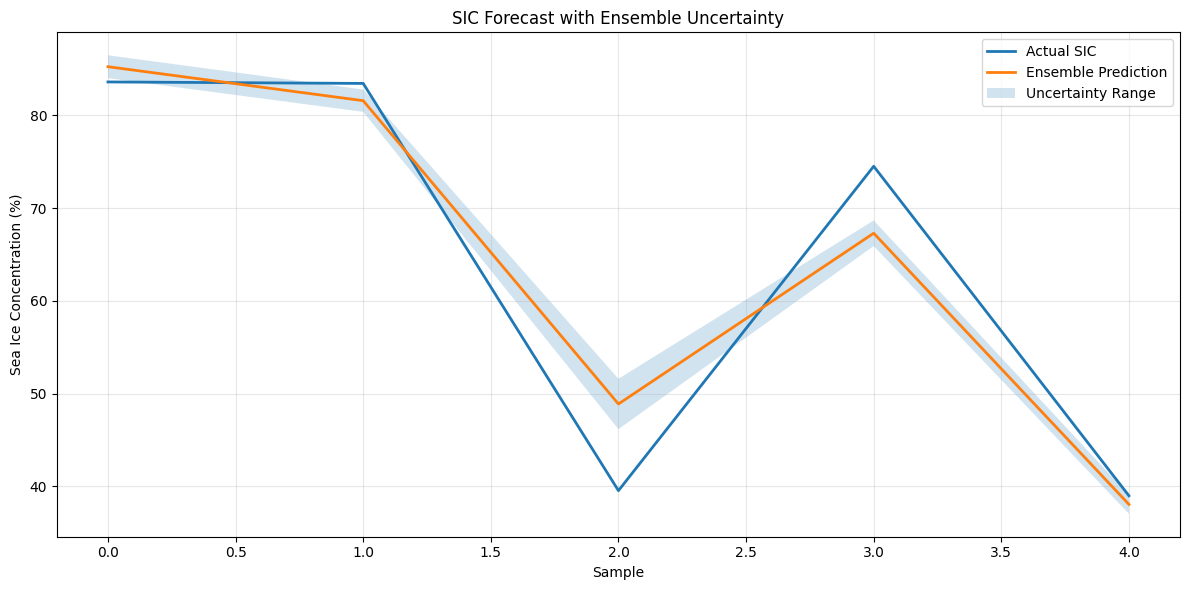

In [21]:
import matplotlib.pyplot as plt
import numpy as np

n = min(
    len(y_test),
    len(result["prediction"]),
    len(result["lower"]),
    len(result["upper"])
)

actual = np.asarray(y_test.iloc[:n])
prediction = np.asarray(result["prediction"][:n])
lower = np.asarray(result["lower"][:n])
upper = np.asarray(result["upper"][:n])

x = np.arange(n)

plt.figure(figsize=(12, 6))

plt.plot(x, actual, label="Actual SIC", linewidth=2)
plt.plot(x, prediction, label="Ensemble Prediction", linewidth=2)

plt.fill_between(
    x,
    lower,
    upper,
    alpha=0.2,
    label="Uncertainty Range"
)

plt.xlabel("Sample")
plt.ylabel("Sea Ice Concentration (%)")
plt.title("SIC Forecast with Ensemble Uncertainty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
def confidence_level(uncertainty):

    if uncertainty < 2:
        return "HIGH"

    elif uncertainty < 5:
        return "MEDIUM"

    else:
        return "LOW"

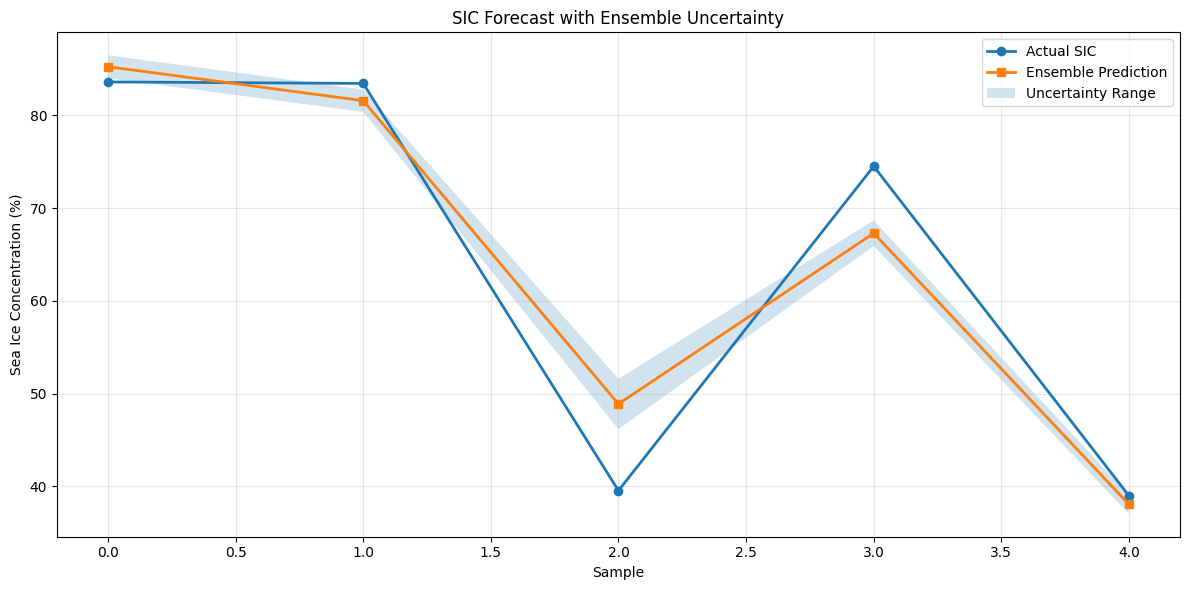

Number of samples plotted: 5


In [22]:
n = min(
    len(y_test),
    len(result["prediction"]),
    len(result["lower"]),
    len(result["upper"])
)

# Convert data to 1D arrays
actual = np.asarray(y_test.iloc[:n]).flatten()
prediction = np.asarray(result["prediction"][:n]).flatten()
lower = np.asarray(result["lower"][:n]).flatten()
upper = np.asarray(result["upper"][:n]).flatten()

# Make sure all arrays have exactly the same length
n = min(
    len(actual),
    len(prediction),
    len(lower),
    len(upper)
)

actual = actual[:n]
prediction = prediction[:n]
lower = lower[:n]
upper = upper[:n]

x = np.arange(n)

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    actual,
    label="Actual SIC",
    linewidth=2,
    marker="o"
)

plt.plot(
    x,
    prediction,
    label="Ensemble Prediction",
    linewidth=2,
    marker="s"
)

plt.fill_between(
    x,
    lower,
    upper,
    alpha=0.2,
    label="Uncertainty Range"
)

plt.xlabel("Sample")
plt.ylabel("Sea Ice Concentration (%)")
plt.title("SIC Forecast with Ensemble Uncertainty")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of samples plotted: {n}")

In [23]:
uncertainty = np.asarray(result["uncertainty"]).flatten()

if len(uncertainty) == 0:
    print("No uncertainty values available.")
else:
    confidence = confidence_level(uncertainty[0])
    print("Confidence:", confidence)

Confidence: HIGH


In [24]:
uncertainty = np.asarray(result["uncertainty"]).flatten()

confidence = [
    confidence_level(u)
    for u in uncertainty
]

print("Confidence:", confidence)

Confidence: ['HIGH', 'HIGH', 'HIGH', 'HIGH', 'HIGH']


In [26]:
uncertainty = np.asarray(result["uncertainty"]).flatten()

confidence_values = [
    confidence_level(float(u))
    for u in uncertainty
]

print("Confidence values:", confidence_values)

# Count each confidence category
confidence_counts = {}

for c in confidence_values:
    confidence_counts[c] = confidence_counts.get(c, 0) + 1

print("\nConfidence Summary:")

for level, count in confidence_counts.items():
    percentage = (count / len(confidence_values)) * 100
    print(f"{level}: {count} samples ({percentage:.1f}%)")

Confidence values: ['HIGH', 'HIGH', 'HIGH', 'HIGH', 'HIGH']

Confidence Summary:
HIGH: 5 samples (100.0%)


In [6]:
import numpy as np


class Iceberg:

    def __init__(
        self,
        latitude,
        longitude,
        mass=1000000
    ):

        self.latitude = latitude
        self.longitude = longitude
        self.mass = mass


class DriftModel:

    def __init__(self):

        # Fraction of iceberg velocity caused
        # by wind.
        self.wind_factor = 0.03

    def calculate_velocity(
        self,
        current_u,
        current_v,
        wind_u,
        wind_v
    ):

        iceberg_u = (
            current_u +
            self.wind_factor * wind_u
        )

        iceberg_v = (
            current_v +
            self.wind_factor * wind_v
        )

        return iceberg_u, iceberg_v


    def move(
        self,
        iceberg,
        current_u,
        current_v,
        wind_u,
        wind_v,
        hours
    ):

        u, v = self.calculate_velocity(
            current_u,
            current_v,
            wind_u,
            wind_v
        )

        # Convert m/s to meters
        seconds = hours * 3600

        displacement_x = u * seconds
        displacement_y = v * seconds

        # Approximate conversion
        # meters → degrees
        latitude_change = (
            displacement_y / 111000
        )

        longitude_change = (
            displacement_x /
            (
                111000 *
                np.cos(
                    np.radians(
                        iceberg.latitude
                    )
                )
            )
        )

        iceberg.latitude += latitude_change
        iceberg.longitude += longitude_change

        return iceberg

In [27]:
iceberg = Iceberg(
    latitude=72.5,
    longitude=-35.2
)

model = DriftModel()

trajectory = []

for day in range(0, 6):

    iceberg = model.move(
        iceberg,

        current_u=0.15,
        current_v=-0.05,

        wind_u=5,
        wind_v=2,

        hours=24
    )

    trajectory.append({
        "day": day + 1,
        "latitude": iceberg.latitude,
        "longitude": iceberg.longitude
    })

    print(
        f"Day {day + 1}: "
        f"Latitude = {iceberg.latitude:.4f}, "
        f"Longitude = {iceberg.longitude:.4f}"
    )

Day 1: Latitude = 72.5078, Longitude = -34.4234
Day 2: Latitude = 72.5156, Longitude = -33.6466
Day 3: Latitude = 72.5234, Longitude = -32.8693
Day 4: Latitude = 72.5311, Longitude = -32.0918
Day 5: Latitude = 72.5389, Longitude = -31.3139
Day 6: Latitude = 72.5467, Longitude = -30.5357


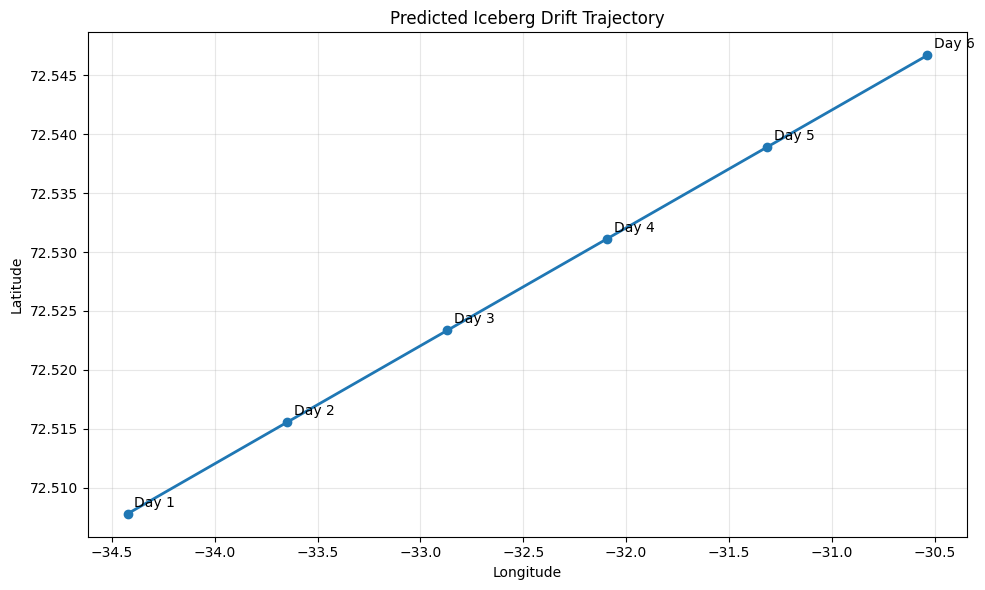

In [28]:
latitudes = [p["latitude"] for p in trajectory]
longitudes = [p["longitude"] for p in trajectory]
days = [p["day"] for p in trajectory]

plt.figure(figsize=(10, 6))

plt.plot(
    longitudes,
    latitudes,
    marker="o",
    linewidth=2
)

for day, lon, lat in zip(days, longitudes, latitudes):
    plt.annotate(
        f"Day {day}",
        (lon, lat),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Predicted Iceberg Drift Trajectory")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
class MeltModel:

    def __init__(
        self,
        base_melt_rate=0.00001
    ):

        self.base_melt_rate = base_melt_rate


    def calculate_melt_rate(
        self,
        sea_temperature,
        current_speed,
        wind_speed
    ):

        temperature_factor = max(
            0,
            sea_temperature + 2
        )

        current_factor = (
            1 + 0.1 * current_speed
        )

        wind_factor = (
            1 + 0.02 * wind_speed
        )

        melt_rate = (
            self.base_melt_rate *
            (1 + temperature_factor) *
            current_factor *
            wind_factor
        )

        return melt_rate


    def update_mass(
        self,
        mass,
        sea_temperature,
        current_speed,
        wind_speed,
        hours
    ):

        melt_rate = self.calculate_melt_rate(
            sea_temperature,
            current_speed,
            wind_speed
        )

        mass_loss = (
            mass *
            melt_rate *
            hours
        )

        new_mass = mass - mass_loss

        return max(new_mass, 0)

In [34]:
import numpy as np


class Iceberg:

    def __init__(self, latitude, longitude, mass=1_000_000):

        self.latitude = latitude
        self.longitude = longitude
        self.mass = mass


class DriftModel:

    def __init__(self, wind_factor=0.03):

        self.wind_factor = wind_factor


    def move(
        self,
        iceberg,
        current_u,
        current_v,
        wind_u,
        wind_v,
        hours=24
    ):

        # Current + wind influence
        u = current_u + self.wind_factor * wind_u
        v = current_v + self.wind_factor * wind_v

        # Convert hours → seconds
        seconds = hours * 3600

        # Displacement in metres
        dx = u * seconds
        dy = v * seconds

        # Convert metres → degrees
        dlat = dy / 111000

        # Avoid problems near the poles
        cos_lat = np.cos(
            np.radians(iceberg.latitude)
        )

        if abs(cos_lat) < 0.01:
            cos_lat = 0.01

        dlon = dx / (111000 * cos_lat)

        # Update position
        iceberg.latitude += dlat
        iceberg.longitude += dlon

        return iceberg

In [35]:
class MeltModel:

    def __init__(self, base_melt_rate=0.00001):

        self.base_melt_rate = base_melt_rate


    def calculate_melt_rate(
        self,
        sea_temperature,
        current_speed,
        wind_speed
    ):

        # Warmer water → more melting
        temperature_factor = max(
            0,
            sea_temperature + 2
        )

        # Faster currents → more melting
        current_factor = (
            1 + 0.1 * current_speed
        )

        # Stronger winds → slightly more melting
        wind_factor = (
            1 + 0.02 * wind_speed
        )

        melt_rate = (
            self.base_melt_rate
            * (1 + temperature_factor)
            * current_factor
            * wind_factor
        )

        return melt_rate


    def update_mass(
        self,
        mass,
        sea_temperature,
        current_speed,
        wind_speed,
        hours=24
    ):

        melt_rate = self.calculate_melt_rate(
            sea_temperature,
            current_speed,
            wind_speed
        )

        mass_loss = (
            mass
            * melt_rate
            * hours
        )

        new_mass = mass - mass_loss

        return max(new_mass, 0)


iceberg = Iceberg(
    latitude=72.5,
    longitude=-35.2,
    mass=1_000_000
)

drift = DriftModel()
melt = MeltModel()


forecast = []


for day in range(1, 11):

    # --------------------------------
    # ENVIRONMENTAL DATA
    # --------------------------------

    current_u = 0.15
    current_v = -0.05

    wind_u = 5
    wind_v = 2

    sea_temperature = -0.5

    current_speed = (
        current_u ** 2 +
        current_v ** 2
    ) ** 0.5

    wind_speed = (
        wind_u ** 2 +
        wind_v ** 2
    ) ** 0.5


    # --------------------------------
    # MOVE ICEBERG
    # --------------------------------

    iceberg = drift.move(
        iceberg,
        current_u,
        current_v,
        wind_u,
        wind_v,
        hours=24
    )


    # --------------------------------
    # MELT ICEBERG
    # --------------------------------

    iceberg.mass = melt.update_mass(
        iceberg.mass,
        sea_temperature,
        current_speed,
        wind_speed,
        hours=24
    )


    # --------------------------------
    # SAVE FORECAST
    # --------------------------------

    forecast.append({

        "day": day,

        "latitude":
            iceberg.latitude,

        "longitude":
            iceberg.longitude,

        "mass":
            iceberg.mass
    })


for row in forecast:

    print(
        f"Day {row['day']} | "
        f"Lat: {row['latitude']:.4f} | "
        f"Lon: {row['longitude']:.4f} | "
        f"Mass: {row['mass']:.0f} kg"
    )

Day 1 | Lat: 72.5078 | Lon: -34.4234 | Mass: 999325 kg
Day 2 | Lat: 72.5156 | Lon: -33.6466 | Mass: 998650 kg
Day 3 | Lat: 72.5234 | Lon: -32.8693 | Mass: 997976 kg
Day 4 | Lat: 72.5311 | Lon: -32.0918 | Mass: 997302 kg
Day 5 | Lat: 72.5389 | Lon: -31.3139 | Mass: 996629 kg
Day 6 | Lat: 72.5467 | Lon: -30.5357 | Mass: 995956 kg
Day 7 | Lat: 72.5545 | Lon: -29.7571 | Mass: 995284 kg
Day 8 | Lat: 72.5623 | Lon: -28.9782 | Mass: 994612 kg
Day 9 | Lat: 72.5701 | Lon: -28.1990 | Mass: 993940 kg
Day 10 | Lat: 72.5778 | Lon: -27.4194 | Mass: 993269 kg


In [36]:
# ---------------------------------
# CREATE ICEBERG
# ---------------------------------

iceberg = Iceberg(
    latitude=72.5,
    longitude=-35.2,
    mass=1_000_000
)


# ---------------------------------
# CREATE MODELS
# ---------------------------------

drift_model = DriftModel()
melt_model = MeltModel()


# ---------------------------------
# FORECAST
# ---------------------------------

forecast = []


for day in range(1, 11):

    # -----------------------------
    # ENVIRONMENTAL CONDITIONS
    # -----------------------------

    # TEMPORARY DEMO VALUES
    # These will later be replaced
    # with real Copernicus data.

    current_u = 0.15
    current_v = -0.05

    wind_u = 5
    wind_v = 2

    sea_temperature = -0.5


    # Calculate speeds

    current_speed = np.sqrt(
        current_u**2 +
        current_v**2
    )

    wind_speed = np.sqrt(
        wind_u**2 +
        wind_v**2
    )


    # -----------------------------
    # MOVE ICEBERG
    # -----------------------------

    iceberg = drift_model.move(
        iceberg,
        current_u,
        current_v,
        wind_u,
        wind_v,
        hours=24
    )


    # -----------------------------
    # MELT ICEBERG
    # -----------------------------

    iceberg.mass = melt_model.update_mass(
        iceberg.mass,
        sea_temperature,
        current_speed,
        wind_speed,
        hours=24
    )


    # -----------------------------
    # SAVE RESULT
    # -----------------------------

    forecast.append({
        "day": day,
        "latitude": iceberg.latitude,
        "longitude": iceberg.longitude,
        "mass": iceberg.mass
    })


# ---------------------------------
# DISPLAY FORECAST
# ---------------------------------

for row in forecast:

    print(
        f"Day {row['day']:2d} | "
        f"Lat: {row['latitude']:.4f} | "
        f"Lon: {row['longitude']:.4f} | "
        f"Mass: {row['mass']:,.0f} kg"
    )

Day  1 | Lat: 72.5078 | Lon: -34.4234 | Mass: 999,325 kg
Day  2 | Lat: 72.5156 | Lon: -33.6466 | Mass: 998,650 kg
Day  3 | Lat: 72.5234 | Lon: -32.8693 | Mass: 997,976 kg
Day  4 | Lat: 72.5311 | Lon: -32.0918 | Mass: 997,302 kg
Day  5 | Lat: 72.5389 | Lon: -31.3139 | Mass: 996,629 kg
Day  6 | Lat: 72.5467 | Lon: -30.5357 | Mass: 995,956 kg
Day  7 | Lat: 72.5545 | Lon: -29.7571 | Mass: 995,284 kg
Day  8 | Lat: 72.5623 | Lon: -28.9782 | Mass: 994,612 kg
Day  9 | Lat: 72.5701 | Lon: -28.1990 | Mass: 993,940 kg
Day 10 | Lat: 72.5778 | Lon: -27.4194 | Mass: 993,269 kg


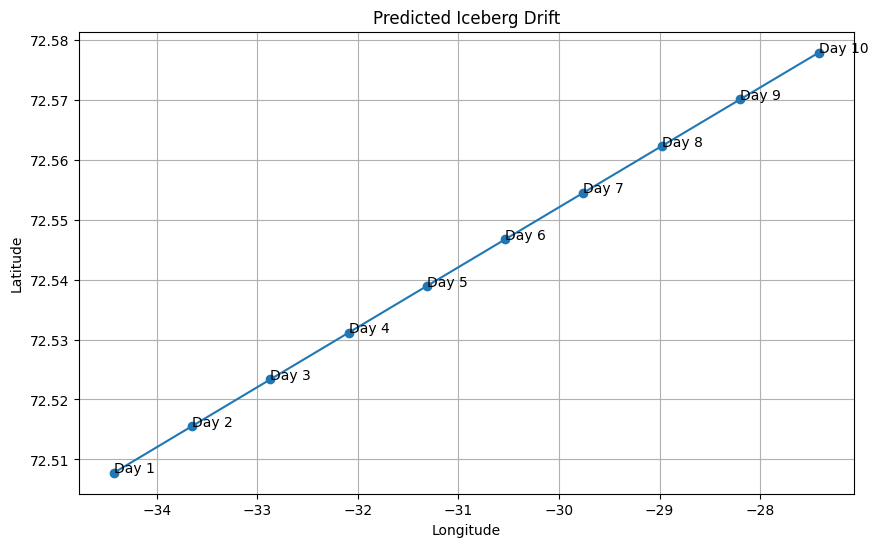

In [37]:
import matplotlib.pyplot as plt

latitudes = [
    row["latitude"]
    for row in forecast
]

longitudes = [
    row["longitude"]
    for row in forecast
]

days = [
    row["day"]
    for row in forecast
]


plt.figure(figsize=(10, 6))

plt.plot(
    longitudes,
    latitudes,
    marker="o"
)

for i in range(len(days)):

    plt.annotate(
        f"Day {days[i]}",
        (
            longitudes[i],
            latitudes[i]
        )
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Predicted Iceberg Drift"
)

plt.grid(True)

plt.show()

In [30]:
current_u = 0.15
current_v = -0.05

wind_u = 5
wind_v = 2

In [31]:
environment = {

    "current_u": 0.153,

    "current_v": -0.047,

    "wind_u": 4.81,

    "wind_v": 2.14,

    "sst": -0.72
}

In [38]:
iceberg = drift.move(
    iceberg,

    environment["current_u"],
    environment["current_v"],

    environment["wind_u"],
    environment["wind_v"],

    hours=24
)

In [39]:
iceberg.mass = melt.update_mass(

    iceberg.mass,

    environment["sst"],

    current_speed,

    wind_speed,

    hours=24
)